In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import json

from utils import graphics

graphics.set_matplotlib_settings()

In [ ]:
sd_card_name = "card_test"
event_timesteps_filename = "led0_event_timesteps"
event_settings_filename = "led0_event_settings"
start_time = 500
stim_duration = 10 # 50ms period for 20Hz
off_duration = 40
total_stims = 5 # 20Hz

# sd_card_name = "card_test"
# event_timesteps_filename = "led1_event_timesteps"
# event_settings_filename = "led1_event_settings"
# start_time = 550
# stim_duration = 10 # 50ms period for 20Hz
# off_duration = 40
# total_stims = 5 # 20Hz

# sd_card_name = "card_test"
# event_timesteps_filename = "led2_event_timesteps"
# event_settings_filename = "led2_event_settings"
# start_time = 500
# stim_duration = 250
# off_duration = 250
# total_stims = 1

# sd_card_name = "card_test"
# event_timesteps_filename = "shutter_event_timesteps"
# event_settings_filename = "shutter_event_settings"
# start_time = 470
# stim_duration = 300
# off_duration = 1
# total_stims = 1

In [4]:
event_timesteps = [0] # first event is always off for everything at 0ms
for i in range(total_stims):
    event_timesteps.append(start_time + i * (stim_duration + off_duration))
    event_timesteps.append(start_time + i * (stim_duration + off_duration) + stim_duration)

In [5]:
stimulus_event_timesteps = np.array(sorted(event_timesteps), dtype=np.uint32)
stimulus_event_timesteps = np.insert(stimulus_event_timesteps, 0, len(stimulus_event_timesteps))  # first element is the size of the array
stimulus_event_settings = np.array([0 if i % 2 == 0 else 1 for i in range(len(stimulus_event_timesteps) - 1)], dtype=np.uint32)
stimulus_event_settings = np.insert(stimulus_event_settings, 0, len(stimulus_event_settings))  # first element is the size of the array

In [6]:
assert len(stimulus_event_timesteps) == len(stimulus_event_settings), "The two arrays must have the same length."
assert stimulus_event_timesteps.dtype == np.uint32, "Timesteps must be integers."
assert stimulus_event_settings.dtype == np.uint32, "Settings must be integers."
assert np.min(stimulus_event_settings) >= 0, "Settings must be non-negative."
assert np.max(stimulus_event_settings[1:]) <= 1, "Settings must be less than or equal to 1."
assert np.min(stimulus_event_timesteps) >= 0, "Timesteps must be non-negative."
assert np.max(stimulus_event_timesteps) <= 10000, "Timesteps must be less than or equal to 10000 (ms in 10s)."

In [7]:
os.makedirs(f"./arduino_sd_cards/{sd_card_name}", exist_ok=True)

with open(f"./arduino_sd_cards/{sd_card_name}/{event_timesteps_filename}.txt", "w", newline="\n") as f:
    f.write("\n".join(str(x) for x in stimulus_event_timesteps))
    f.write("\n")

with open(f"./arduino_sd_cards/{sd_card_name}/{event_settings_filename}.txt", "w", newline="\n") as f:
    f.write("\n".join(str(x) for x in stimulus_event_settings))
    f.write("\n")

In [8]:
print(len(stimulus_event_timesteps))

4


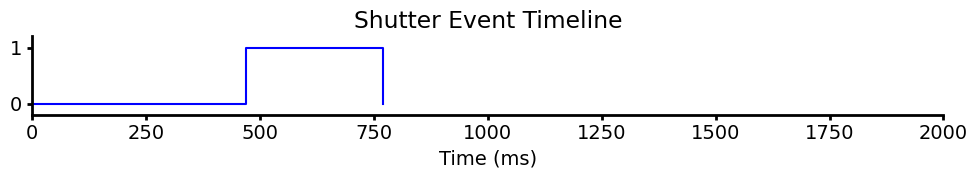

In [9]:
plt.figure(figsize=(10, 2))
plt.step(stimulus_event_timesteps[1:], stimulus_event_settings[1:], where='post', color='blue')
plt.xlim(0, 2000)
plt.ylim(-0.2, 1.2)
plt.xlabel('Time (ms)')
plt.yticks([0, 1])
plt.title(event_timesteps_filename.split("_")[0].capitalize() + " Event Timeline")
plt.savefig(f"./arduino_sd_cards/{sd_card_name}/{event_timesteps_filename.split('_')[0]}_timeline.png", bbox_inches='tight')
plt.show()

In [10]:
generation_params_dict = {
    "event_timesteps_filename": event_settings_filename,
    "event_settings_filename": event_settings_filename,
    "start_time": start_time,
    "stim_duration": stim_duration,
    "off_duration": off_duration,
    "total_stims": total_stims
}
print(generation_params_dict)
with open(f"./arduino_sd_cards/{sd_card_name}/{event_timesteps_filename.split('_')[0]}_generation_params.json", "w") as file:
    json.dump(generation_params_dict, file)

{'event_timesteps_filename': 'shutter_event_settings', 'event_settings_filename': 'shutter_event_settings', 'start_time': 470, 'stim_duration': 300, 'off_duration': 1, 'total_stims': 1}
